# SAHI Dataset Slicer for cropped image

## Step 1: Configuration


In [1]:
#setting up the paths
INPUT_DIR = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo"

# Output
OUTPUT_DIR = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced"

SLICE_SIZE = 640        # Size of each slice (should match training imgsz)
OVERLAP_RATIO = 0.4     # 20% overlap between slices
MIN_VISIBILITY = 0.3    # Include bbox if at least 30% is visible in slice
INCLUDE_EMPTY = False   # Set True to include slices without any objects

print("Configuration:")
print(f"  Input:  {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Slice size: {SLICE_SIZE}x{SLICE_SIZE}")
print(f"  Overlap: {OVERLAP_RATIO*100:.0f}%")
print(f"  Min visibility: {MIN_VISIBILITY*100:.0f}%")

Configuration:
  Input:  /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo
  Output: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced
  Slice size: 640x640
  Overlap: 40%
  Min visibility: 30%


## Step 2: Import Libraries

In [2]:
import os
import shutil
from pathlib import Path
from typing import List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


## Step 3: Verify Input Dataset

In [3]:
input_path = Path(INPUT_DIR)

# Check directories exist
train_imgs = list((input_path / 'images' / 'train').glob('*.jpg'))
val_imgs = list((input_path / 'images' / 'val').glob('*.jpg'))
train_labels = list((input_path / 'labels' / 'train').glob('*.txt'))
val_labels = list((input_path / 'labels' / 'val').glob('*.txt'))

print("Input Dataset:")
print(f"  Train images: {len(train_imgs)}")
print(f"  Val images:   {len(val_imgs)}")
print(f"  Train labels: {len(train_labels)}")
print(f"  Val labels:   {len(val_labels)}")

# Check image dimensions
if train_imgs:
    sample = cv2.imread(str(train_imgs[0]))
    h, w = sample.shape[:2]
    print(f"\nImage dimensions: {w} x {h}")
    
    # Calculate how many slices per image
    stride = int(SLICE_SIZE * (1 - OVERLAP_RATIO))
    n_x = len(range(0, max(1, w - SLICE_SIZE + 1), stride)) + (1 if w > SLICE_SIZE else 0)
    n_y = len(range(0, max(1, h - SLICE_SIZE + 1), stride)) + (1 if h > SLICE_SIZE else 0)
    
    print(f"\nWith {SLICE_SIZE}x{SLICE_SIZE} slices and {OVERLAP_RATIO*100:.0f}% overlap:")
    print(f"  ~{n_x} slices horizontally")
    print(f"  ~{n_y} slices vertically")
    print(f"  ~{n_x * n_y} slices per image")
    print(f"  ~{n_x * n_y * len(train_imgs)} total train slices (before filtering empty)")

Input Dataset:
  Train images: 292
  Val images:   74
  Train labels: 292
  Val labels:   74

Image dimensions: 2048 x 800

With 640x640 slices and 40% overlap:
  ~5 slices horizontally
  ~2 slices vertically
  ~10 slices per image
  ~2920 total train slices (before filtering empty)


## Step 4: Visualize Slicing Strategy

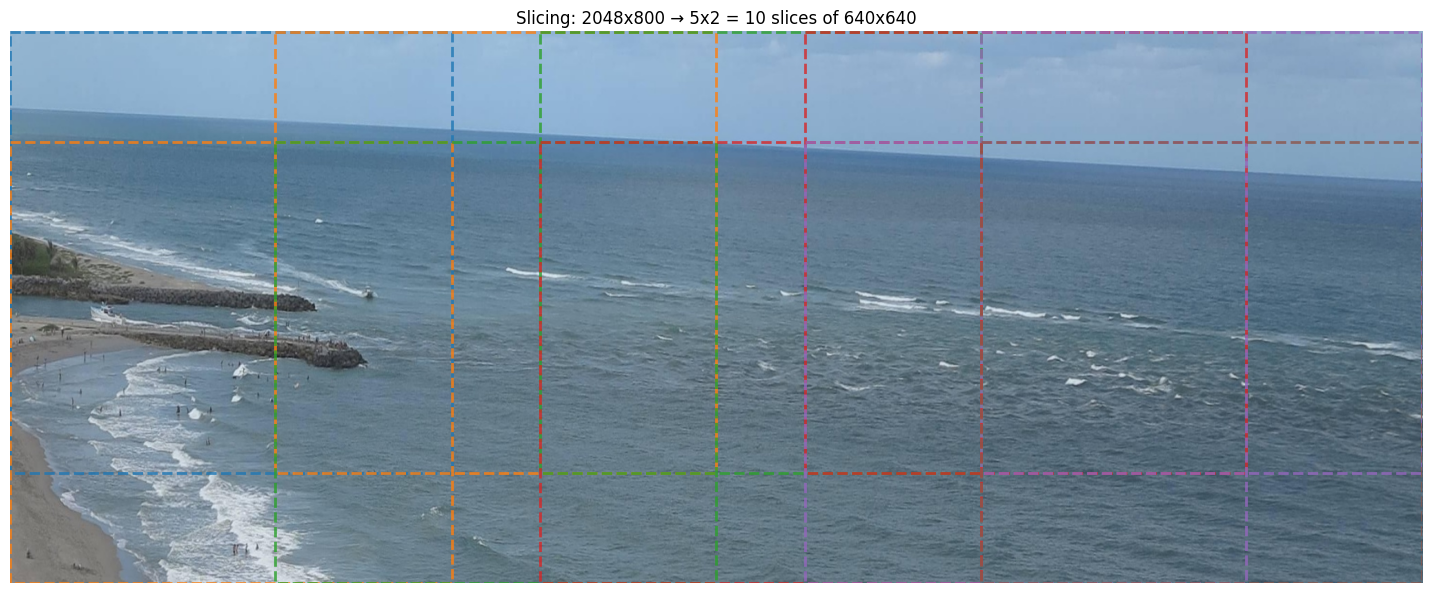


This image will produce 10 slices


In [4]:
def visualize_slicing(image_path, slice_size=640, overlap_ratio=0.2):
    """Visualize how an image will be sliced."""
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    stride = int(slice_size * (1 - overlap_ratio))
    
    # Calculate slice positions
    y_positions = list(range(0, max(1, h - slice_size + 1), stride))
    x_positions = list(range(0, max(1, w - slice_size + 1), stride))
    
    if h > slice_size and (y_positions[-1] + slice_size) < h:
        y_positions.append(h - slice_size)
    if w > slice_size and (x_positions[-1] + slice_size) < w:
        x_positions.append(w - slice_size)
    
    # Draw grid
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    ax.imshow(image)
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for i, y in enumerate(y_positions):
        for j, x in enumerate(x_positions):
            color = colors[(i + j) % len(colors)]
            rect = plt.Rectangle((x, y), slice_size, slice_size,
                                  linewidth=2, edgecolor=color, facecolor='none',
                                  linestyle='--', alpha=0.8)
            ax.add_patch(rect)
    
    ax.set_title(f'Slicing: {w}x{h} → {len(x_positions)}x{len(y_positions)} = {len(x_positions)*len(y_positions)} slices of {slice_size}x{slice_size}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return len(x_positions) * len(y_positions)

# Visualize on first training image
if train_imgs:
    n_slices = visualize_slicing(train_imgs[0], SLICE_SIZE, OVERLAP_RATIO)
    print(f"\nThis image will produce {n_slices} slices")

## Step 5: Define Slicing Functions

In [5]:
def slice_image_and_labels(
    image_path: str,
    label_path: str,
    slice_size: int = 640,
    overlap_ratio: float = 0.2,
    min_visibility: float = 0.3,
) -> List[Tuple[np.ndarray, List[str], str]]:
    """
    Slice an image and its YOLO labels into tiles.
    
    Args:
        image_path: Path to image file
        label_path: Path to YOLO label file
        slice_size: Size of each square slice
        overlap_ratio: Overlap between slices (0.2 = 20%)
        min_visibility: Minimum fraction of bbox visible to include
    
    Returns:
        List of (slice_image, yolo_labels, slice_name) tuples
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read {image_path}")
        return []
    
    img_h, img_w = image.shape[:2]
    
    # Load YOLO labels
    labels = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    w = float(parts[3])
                    h = float(parts[4])
                    labels.append((cls, x_center, y_center, w, h))
    
    # Calculate slice positions
    stride = int(slice_size * (1 - overlap_ratio))
    
    y_positions = list(range(0, max(1, img_h - slice_size + 1), stride))
    x_positions = list(range(0, max(1, img_w - slice_size + 1), stride))
    
    # Ensure we cover edges
    if img_h > slice_size and (y_positions[-1] + slice_size) < img_h:
        y_positions.append(img_h - slice_size)
    if img_w > slice_size and (x_positions[-1] + slice_size) < img_w:
        x_positions.append(img_w - slice_size)
    
    if img_h <= slice_size:
        y_positions = [0]
    if img_w <= slice_size:
        x_positions = [0]
    
    base_name = Path(image_path).stem
    slices = []
    slice_idx = 0
    
    for y in y_positions:
        for x in x_positions:
            # Extract slice
            slice_w = min(slice_size, img_w - x)
            slice_h = min(slice_size, img_h - y)
            slice_img = image[y:y+slice_h, x:x+slice_w]
            
            # Pad if necessary
            if slice_w < slice_size or slice_h < slice_size:
                padded = np.zeros((slice_size, slice_size, 3), dtype=np.uint8)
                padded[:slice_h, :slice_w] = slice_img
                slice_img = padded
            
            # Transform labels
            slice_labels = []
            for cls, x_center, y_center, w, h in labels:
                # Convert to pixel coords
                bbox_x_center = x_center * img_w
                bbox_y_center = y_center * img_h
                bbox_w = w * img_w
                bbox_h = h * img_h
                
                # Bbox corners
                bbox_x1 = bbox_x_center - bbox_w / 2
                bbox_y1 = bbox_y_center - bbox_h / 2
                bbox_x2 = bbox_x_center + bbox_w / 2
                bbox_y2 = bbox_y_center + bbox_h / 2
                
                # Slice bounds
                slice_x1, slice_y1 = x, y
                slice_x2, slice_y2 = x + slice_size, y + slice_size
                
                # Intersection
                inter_x1 = max(bbox_x1, slice_x1)
                inter_y1 = max(bbox_y1, slice_y1)
                inter_x2 = min(bbox_x2, slice_x2)
                inter_y2 = min(bbox_y2, slice_y2)
                
                if inter_x1 >= inter_x2 or inter_y1 >= inter_y2:
                    continue
                
                # Check visibility
                inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
                bbox_area = bbox_w * bbox_h
                visibility = inter_area / bbox_area if bbox_area > 0 else 0
                
                if visibility < min_visibility:
                    continue
                
                # Transform to slice coords
                new_x1 = inter_x1 - slice_x1
                new_y1 = inter_y1 - slice_y1
                new_x2 = inter_x2 - slice_x1
                new_y2 = inter_y2 - slice_y1
                
                # Convert to YOLO format
                new_x_center = (new_x1 + new_x2) / 2 / slice_size
                new_y_center = (new_y1 + new_y2) / 2 / slice_size
                new_w = (new_x2 - new_x1) / slice_size
                new_h = (new_y2 - new_y1) / slice_size
                
                # Clamp
                new_x_center = max(0, min(1, new_x_center))
                new_y_center = max(0, min(1, new_y_center))
                new_w = max(0, min(1, new_w))
                new_h = max(0, min(1, new_h))
                
                # Skip tiny boxes
                if new_w * slice_size < 3 or new_h * slice_size < 3:
                    continue
                
                slice_labels.append(f"{cls} {new_x_center:.6f} {new_y_center:.6f} {new_w:.6f} {new_h:.6f}")
            
            slice_name = f"{base_name}_slice_{slice_idx:03d}"
            slices.append((slice_img, slice_labels, slice_name))
            slice_idx += 1
    
    return slices

print("Slicing functions defined!")

Slicing functions defined!


## Step 6: Test Slicing on One Image

In [6]:
# Test on first image
if train_imgs:
    test_img = str(train_imgs[0])
    test_label = str(input_path / 'labels' / 'train' / (train_imgs[0].stem + '.txt'))
    
    print(f"Testing on: {Path(test_img).name}")
    
    slices = slice_image_and_labels(
        test_img, test_label,
        slice_size=SLICE_SIZE,
        overlap_ratio=OVERLAP_RATIO,
        min_visibility=MIN_VISIBILITY
    )
    
    print(f"Generated {len(slices)} slices")
    
    # Count slices with objects
    with_objects = sum(1 for _, labels, _ in slices if len(labels) > 0)
    print(f"Slices with objects: {with_objects}")
    print(f"Empty slices: {len(slices) - with_objects}")

Testing on: a101524q_jpg.rf.c9ecd8aa38b5494033de3bdf6d49f4aa.jpg
Generated 10 slices
Slices with objects: 4
Empty slices: 6


## Step 7: Visualize Sample Slices

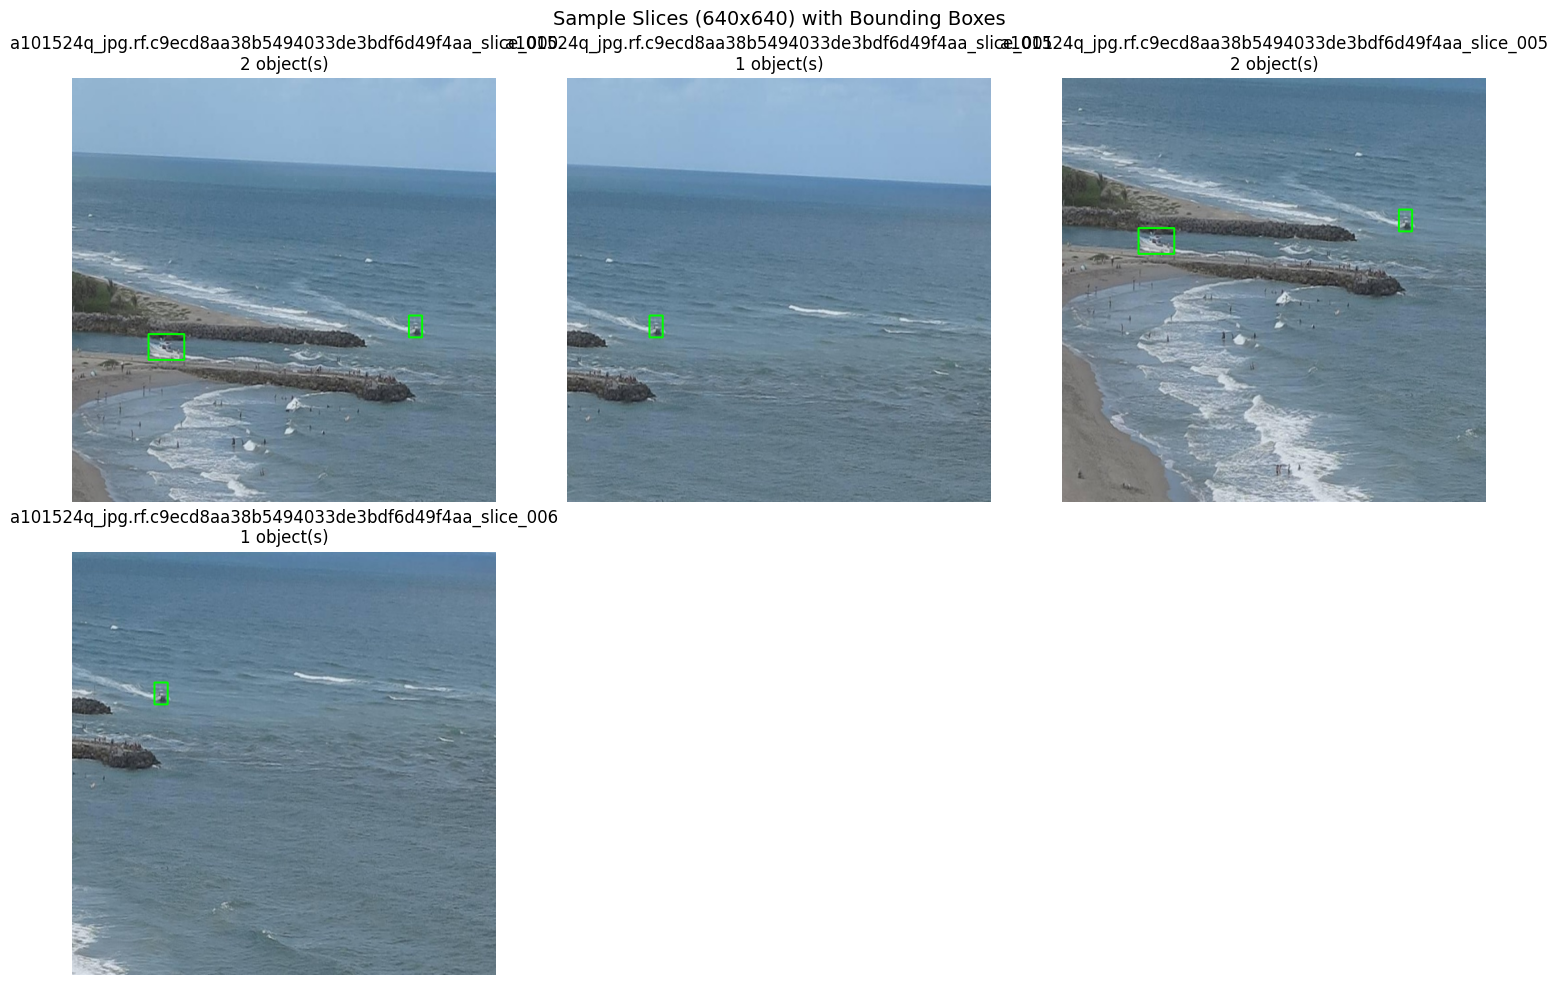

In [7]:
def draw_yolo_boxes(image, labels, color=(0, 255, 0), thickness=2):
    """Draw YOLO format bounding boxes on image."""
    img = image.copy()
    h, w = img.shape[:2]
    
    for label in labels:
        parts = label.split()
        if len(parts) >= 5:
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    
    return img

# Show some slices with objects
if train_imgs:
    slices_with_objects = [(img, labels, name) for img, labels, name in slices if len(labels) > 0]
    
    if slices_with_objects:
        n_show = min(6, len(slices_with_objects))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for i in range(n_show):
            img, labels, name = slices_with_objects[i]
            img_with_boxes = draw_yolo_boxes(img, labels)
            img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
            
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"{name}\n{len(labels)} object(s)")
            axes[i].axis('off')
        
        # Hide unused axes
        for i in range(n_show, len(axes)):
            axes[i].axis('off')
        
        plt.suptitle(f"Sample Slices ({SLICE_SIZE}x{SLICE_SIZE}) with Bounding Boxes", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("No slices with objects found in test image")

## Step 8: Slice Entire Dataset

In [8]:
def slice_yolo_dataset(
    input_dir: str,
    output_dir: str,
    slice_size: int = 640,
    overlap_ratio: float = 0.4,
    min_visibility: float = 0.3,
    include_empty: bool = False,
):
    """
    Slice an entire YOLO dataset into tiles.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Clean and create output directories
    if output_path.exists():
        shutil.rmtree(output_path)
    
    for split in ['train', 'val']:
        (output_path / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_path / 'labels' / split).mkdir(parents=True, exist_ok=True)
    
    stats = {
        'total_images': 0,
        'total_slices': 0,
        'slices_with_objects': 0,
        'total_annotations': 0,
    }
    
    for split in ['train', 'val']:
        print(f"\nProcessing {split} set...")
        
        images_dir = input_path / 'images' / split
        labels_dir = input_path / 'labels' / split
        
        if not images_dir.exists():
            print(f"  Warning: {images_dir} not found")
            continue
        
        image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
        
        for i, img_path in enumerate(image_files):
            label_path = labels_dir / (img_path.stem + '.txt')
            
            slices = slice_image_and_labels(
                str(img_path),
                str(label_path),
                slice_size=slice_size,
                overlap_ratio=overlap_ratio,
                min_visibility=min_visibility,
            )
            
            stats['total_images'] += 1
            
            for slice_img, slice_labels, slice_name in slices:
                if not include_empty and len(slice_labels) == 0:
                    continue
                
                # Save image
                out_img_path = output_path / 'images' / split / f"{slice_name}.jpg"
                cv2.imwrite(str(out_img_path), slice_img)
                
                # Save labels
                out_label_path = output_path / 'labels' / split / f"{slice_name}.txt"
                with open(out_label_path, 'w') as f:
                    f.write('\n'.join(slice_labels))
                
                stats['total_slices'] += 1
                if len(slice_labels) > 0:
                    stats['slices_with_objects'] += 1
                stats['total_annotations'] += len(slice_labels)
            
            if (i + 1) % 50 == 0:
                print(f"  Processed {i + 1}/{len(image_files)} images...")
        
        print(f"  Completed: {len(image_files)} images")
    
    # Create data.yaml
    data_yaml = f"""path: {output_path.absolute()}
train: images/train
val: images/val
nc: 1
names:
  0: Boat
"""
    
    yaml_path = output_path / 'data.yaml'
    with open(yaml_path, 'w') as f:
        f.write(data_yaml)
    
    return str(yaml_path), stats

print("Dataset slicing function defined!")

Dataset slicing function defined!


In [9]:
# Run the slicing!
print("="*60)
print("SLICING DATASET")
print("="*60)

data_yaml_path, stats = slice_yolo_dataset(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    slice_size=SLICE_SIZE,
    overlap_ratio=OVERLAP_RATIO,
    min_visibility=MIN_VISIBILITY,
    include_empty=INCLUDE_EMPTY,
)

print(f"\n{'='*60}")
print("SLICING COMPLETE!")
print(f"{'='*60}")
print(f"  Original images:      {stats['total_images']}")
print(f"  Total slices:         {stats['total_slices']}")
print(f"  Slices with objects:  {stats['slices_with_objects']}")
print(f"  Total annotations:    {stats['total_annotations']}")
print(f"  Slice size:           {SLICE_SIZE}x{SLICE_SIZE}")
print(f"  Overlap:              {OVERLAP_RATIO*100:.0f}%")
print(f"{'='*60}")
print(f"\nOutput: {OUTPUT_DIR}")
print(f"data.yaml: {data_yaml_path}")

SLICING DATASET

Processing train set...
  Processed 50/292 images...
  Processed 100/292 images...
  Processed 150/292 images...
  Processed 200/292 images...
  Processed 250/292 images...
  Completed: 292 images

Processing val set...
  Processed 50/74 images...
  Completed: 74 images

SLICING COMPLETE!
  Original images:      366
  Total slices:         1893
  Slices with objects:  1893
  Total annotations:    3136
  Slice size:           640x640
  Overlap:              40%

Output: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced
data.yaml: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/data.yaml


## Step 9: Verify Sliced Dataset

In [21]:
output_path = Path(OUTPUT_DIR)

train_slices = list((output_path / 'images' / 'train').glob('*.jpg'))
val_slices = list((output_path / 'images' / 'val').glob('*.jpg'))

print("Sliced Dataset:")
print(f"  Train slices: {len(train_slices)}")
print(f"  Val slices:   {len(val_slices)}")

if train_slices:
    sample = cv2.imread(str(train_slices[0]))
    print(f"  Slice size:   {sample.shape[1]} x {sample.shape[0]}")

Sliced Dataset:
  Train slices: 1462
  Val slices:   431
  Slice size:   640 x 640


## Step 10: Train on Sliced Dataset

Now train YOLO with `imgsz=640` (matching slice size).

In [10]:
from ultralytics import YOLO

# Load model
model = YOLO('yolo26s.pt')

# Train on sliced dataset
results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=SLICE_SIZE,      # Now matches slice size!
    batch=16,              # Can use larger batch with smaller images
    
    # Augmentations
    mosaic=0.5,
    scale=0.2,
    fliplr=0.5,
    flipud=0.0,
    
    # Training
    patience=50,
    save=True,
    plots=True,
    
    project='jupiter_inlet',
    name=f'train_sahi_{SLICE_SIZE}',
)

New https://pypi.org/project/ultralytics/8.4.12 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.11 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 245.6±139.4 MB/s, size: 83.9 KB)
val: Scanning /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/labels/val... 431 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 431/431 2.0Kit/s 0.2s<0.0s
val: New cache created: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/labels/val.cache


/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_6403/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_6403
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.48G      2.154      3.418   0.003725          6        640: 100% ━━━━━━━━━━━━ 92/92 4.6it/s 20.0s0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.7it/s 3.8s<0.1s
                   all        431        773       0.73  

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/100      5.24G      1.031     0.3341   0.001356          6        640: 100% ━━━━━━━━━━━━ 92/92 11.7it/s 7.9s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 16.4it/s 0.9s0.1s
                   all        431        773      0.869      0.842      0.879      0.432

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/100      5.24G      1.003     0.3194   0.001299          8        640: 100% ━━━━━━━━━━━━ 92/92 13.7it/s 6.7s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 16.6it/s 0.8s0.1s
                   all        431        773      0.892       0.82      0.884      0.439

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/100      5.24G     0.9943     0.3296   0.001298          6        640: 

In [11]:
from ultralytics import YOLO

model = YOLO('yolo26m.pt')  # Medium model instead of small

results = model.train(
    data=data_yaml_path,
    epochs=200,              # More epochs
    imgsz=640,
    batch=8,                 # Adjust for larger model
    
    patience=30,             # Earlier stopping if no improvement
    
    # Same augmentations
    mosaic=0.5,
    scale=0.2,
    fliplr=0.5,
    
    project='jupiter_inlet',
    name='train_sahi_640_medium',
)

New https://pypi.org/project/ultralytics/8.4.12 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.11 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo2

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 46.2±78.0 MB/s, size: 84.4 KB)
val: Scanning /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/labels/val... 344 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 344/344 1.9Kit/s 0.2s<0.3s
val: New cache created: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced/labels/val.cache


/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_640_medium2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 124 weight(decay=0.0), 136 weight(decay=0.0005), 136 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_640_medium2
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      4.76G      2.225      5.841   0.003904          7        640: 100% ━━━━━━━━━━━━ 146/146 7.6it/s 19.1s<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 6.4it/s 3.5s<0.1s
                   all        344        

## Step 11: Inference with SAHI

Use SAHI to run inference on full-size images by slicing them the same way.

In [14]:
# Install SAHI if needed
!pip install -q sahi
print("SAHI installed!")


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
SAHI installed!

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [23]:
import sys
!{sys.executable} -m pip install click fire "shapely>=2.0.0" "opencv-python<=4.11.0.86"

  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached fire-0.7.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached shapely-2.1.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (63.0 MB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached fire-0.7.1-py3-none-any.whl (115 kB)
Using cached shapely-2.1.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.1 MB)
Using cached termcolor-3.3.0-py3-none-any.whl (7.7 kB)
  Attempting uninstall: opencv-python━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [shapely]
    Found existing installation: opencv-python 4.13.0.90━━━━━━ 1/5 [shapely]
    Uninstalling opencv-python-4.13.0.90:0m━━━━━━━━━━━━━━━━━━━━━━━ 2/5 [opencv-

In [24]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# Update this path to your trained model
MODEL_PATH = f"/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_{SLICE_SIZE}/weights/best.pt"

# Load model for SAHI
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda:0"
)

print(f"Model loaded: {MODEL_PATH}")

Model loaded: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_sahi_640/weights/best.pt


In [25]:
# Run SAHI inference on a preprocessed image (2048x800)
test_images = list(Path(INPUT_DIR).glob('images/val/*.jpg'))

if test_images:
    test_img = str(test_images[0])
    print(f"Testing SAHI on: {test_img}")
    
    result = get_sliced_prediction(
        image=test_img,
        detection_model=detection_model,
        slice_height=SLICE_SIZE,
        slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP_RATIO,
        overlap_width_ratio=OVERLAP_RATIO,
    )
    
    print(f"Detected {len(result.object_prediction_list)} objects")
    
    # Visualize
    result.export_visuals(export_dir="sahi_results/")
    print("Results saved to sahi_results/")

Testing SAHI on: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/images/val/s230914u_jpg.rf.3ec2ca41d9d3964ea8d3c4e351d6ef02.jpg
Performing prediction on 8 slices.
Detected 7 objects
Results saved to sahi_results/


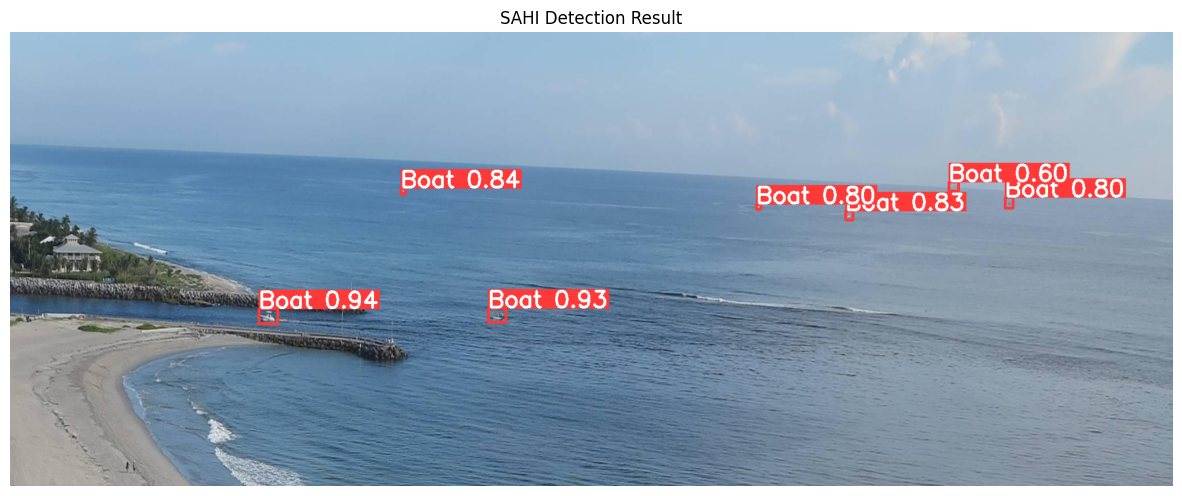

In [26]:
# Display SAHI result
from PIL import Image
import os

result_files = list(Path("sahi_results").glob("*.png"))
if result_files:
    img = Image.open(result_files[0])
    plt.figure(figsize=(15, 6))
    plt.imshow(img)
    plt.title("SAHI Detection Result")
    plt.axis('off')
    plt.show()